# pltx Showcase Notebook

A comprehensive walkthrough of all `pltx` features, translated from `examples/showcase.py`.

> **Sections**
> 1. Setup & style initialisation
> 2. Line outlines for better visibility
> 3. Centreines & hybrid enhancements
> 4. Color intensity variations
> 5. Reference lines & highlighted regions
> 6. Log scale with color cycling
> 7. Accessibility – progressive line widths
> 8. Styled bar charts
> 9. Styled histograms
> 10. Error bars
> 11. Markers with outlines
> 12. **Pasqal colormap** (from `cmap/`)

## 1 · Setup

In [2]:
import sys
import os

# Make sure we can import pltx from the repo root
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import matplotlib.pyplot as mpl_plt
import pltx.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Common data used throughout the notebook
x  = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x) * np.exp(-0.1 * x)
noise = 0.1 * np.random.randn(len(x))

# Initialise global style
plt.initialize_style(
    palette_name='plasma_r',
    palette_size=10,
    font_size_medium=11,
    font_size_large=13,
    use_tex=False,
)
print('pltx ready ✓')

pltx ready ✓


## 2 · Line Outlines for Better Visibility

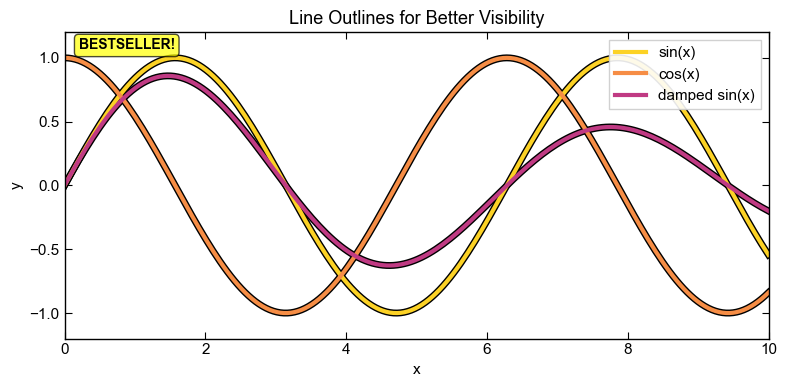

In [3]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

plt.plot_styled(x, y1, color_idx=0, linewidth=3, label='sin(x)',
                outline=True, outline_width=5, ax=ax)
plt.plot_styled(x, y2, color_idx=2, linewidth=3, label='cos(x)',
                outline=True, outline_width=5, ax=ax)
plt.plot_styled(x, y3, color_idx=5, linewidth=3, label='damped sin(x)',
                outline=True, outline_width=5, ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Line Outlines for Better Visibility',
               grid=False, xlim=(0, 10), ylim=(-1.2, 1.2))
ax.legend(loc='upper right', framealpha=0.9)
ax.text(0.02, 0.98, 'BESTSELLER!', transform=ax.transAxes,
        fontsize=10, fontweight='bold', va='top',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
mpl_plt.tight_layout()
mpl_plt.show()

## 3 · Centrelines & Hybrid Enhancements

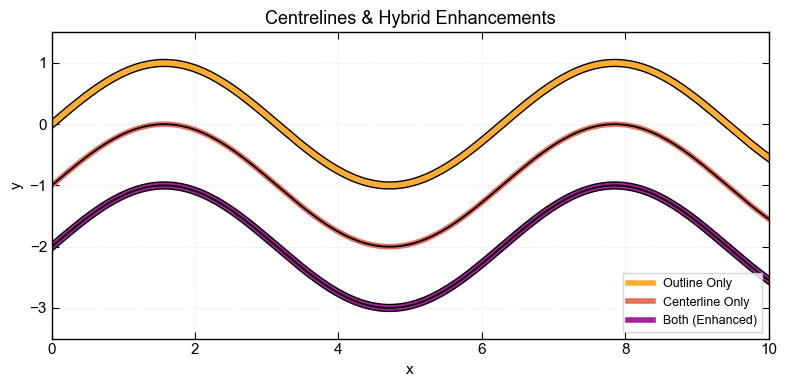

In [4]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

plt.plot_styled(x, y1,     color_idx=1, linewidth=4, label='Outline Only',
                outline=True, ax=ax)
plt.plot_styled(x, y1 - 1, color_idx=3, linewidth=4, label='Centerline Only',
                centerline=True, ax=ax)
plt.plot_styled(x, y1 - 2, color_idx=6, linewidth=4, label='Both (Enhanced)',
                outline=True, centerline=True, ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Centrelines & Hybrid Enhancements',
               grid=True, xlim=(0, 10), ylim=(-3.5, 1.5))
ax.legend(loc='lower right', fontsize=9)
mpl_plt.tight_layout()
mpl_plt.show()

## 4 · Color Intensity Variations

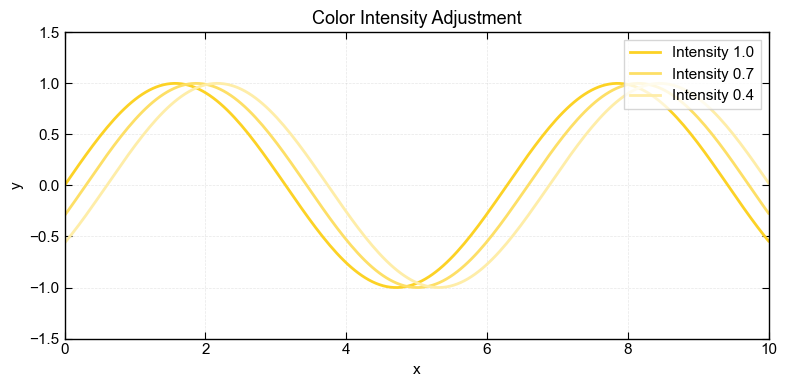

In [5]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

for i, intensity in enumerate([1.0, 0.7, 0.4]):
    plt.plot_styled(x, np.sin(x - i * 0.3),
                    color_idx=0, color_intensity=intensity,
                    linewidth=2, label=f'Intensity {intensity}', ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Color Intensity Adjustment',
               grid=True, xlim=(0, 10), ylim=(-1.5, 1.5))
ax.legend(loc='upper right')
mpl_plt.tight_layout()
mpl_plt.show()

## 5 · Reference Lines & Highlighted Regions

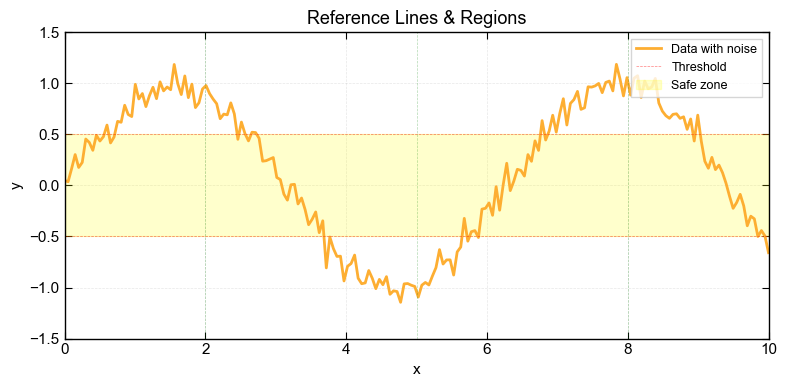

In [6]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

plt.plot_styled(x, y1 + noise, color_idx=1, linewidth=2,
               label='Data with noise', ax=ax)
plt.add_reference_line(horizontal=[0.5, -0.5], color='red',
                       linestyle='--', alpha=0.5, label='Threshold', ax=ax)
plt.add_reference_line(vertical=[2, 5, 8], color='green', alpha=0.3, ax=ax)
plt.add_highlight_region(ymin=-0.5, ymax=0.5, color='yellow',
                         alpha=0.2, label='Safe zone', ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Reference Lines & Regions',
               grid=True, xlim=(0, 10), ylim=(-1.5, 1.5))
ax.legend(loc='upper right', fontsize=9)
mpl_plt.tight_layout()
mpl_plt.show()

## 6 · Log Scale with Auto Color Cycling

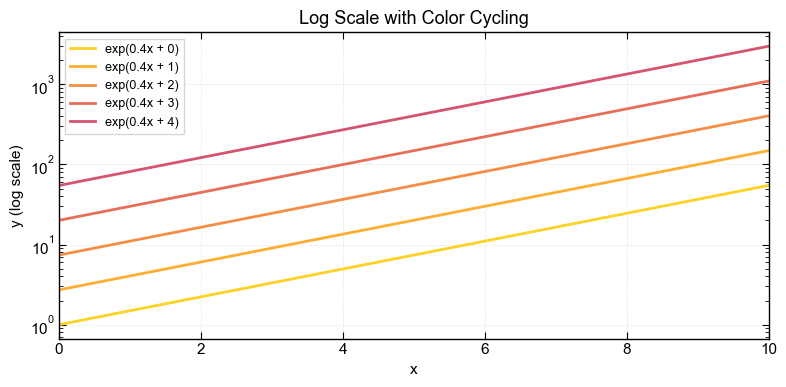

In [7]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

for i in range(5):
    plt.plot_styled(x, np.exp(0.4 * x + i), color_idx=i,
                    linewidth=2, label=f'exp(0.4x + {i})', ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y (log scale)',
               title='Log Scale with Color Cycling',
               yscale='log', grid=True, xlim=(0, 10))
ax.legend(loc='upper left', fontsize=9)
mpl_plt.tight_layout()
mpl_plt.show()

## 7 · Accessibility – Progressive Line Widths

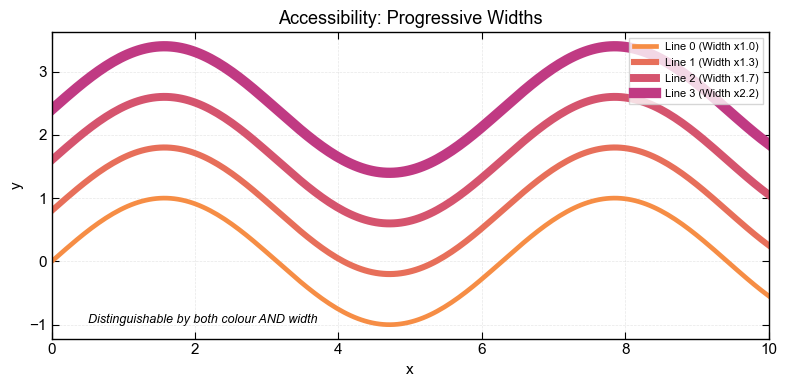

In [8]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

with plt.style_context('default', vary_linewidth=True):
    for i in range(4):
        plt.plot_styled(x, np.sin(x) + i * 0.8, color_idx=i + 2,
                        label=f'Line {i} (Width x{1.3**i:.1f})', ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Accessibility: Progressive Widths',
               grid=True, xlim=(0, 10))
ax.legend(loc='upper right', fontsize=8)
ax.text(0.05, 0.05, 'Distinguishable by both colour AND width',
        transform=ax.transAxes, fontsize=9, style='italic')
mpl_plt.tight_layout()
mpl_plt.show()

## 8 · Styled Bar Charts

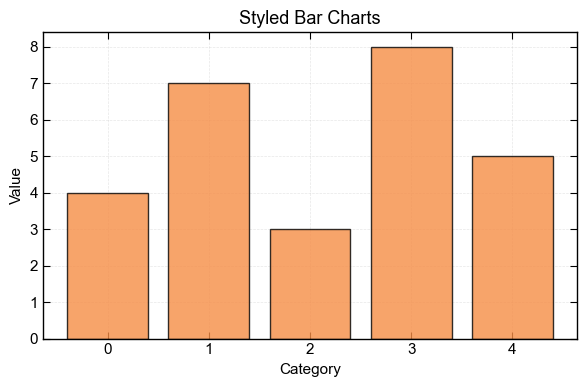

In [9]:
fig, ax = mpl_plt.subplots(figsize=(6, 4))

plt.bar_styled(['A', 'B', 'C', 'D', 'E'], [4, 7, 3, 8, 5],
               color_idx=2, alpha=0.8, ax=ax)
plt.setup_axis(ax, xlabel='Category', ylabel='Value',
               title='Styled Bar Charts', grid=True)
mpl_plt.tight_layout()
mpl_plt.show()

## 9 · Styled Histograms

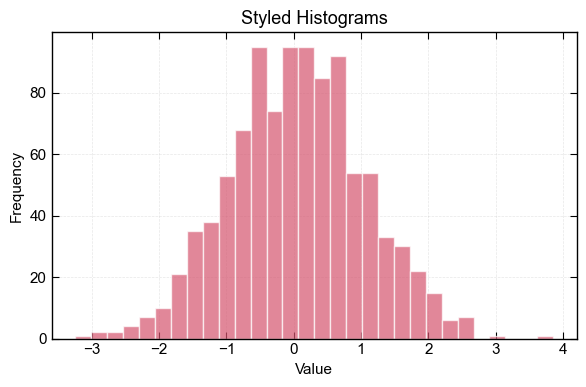

In [10]:
fig, ax = mpl_plt.subplots(figsize=(6, 4))

data = np.random.normal(0, 1, 1000)
plt.hist_styled(data, bins=30, color_idx=4, alpha=0.7,
               edgecolor='white', ax=ax)
plt.setup_axis(ax, xlabel='Value', ylabel='Frequency',
               title='Styled Histograms', grid=True)
mpl_plt.tight_layout()
mpl_plt.show()

## 10 · Error Bars

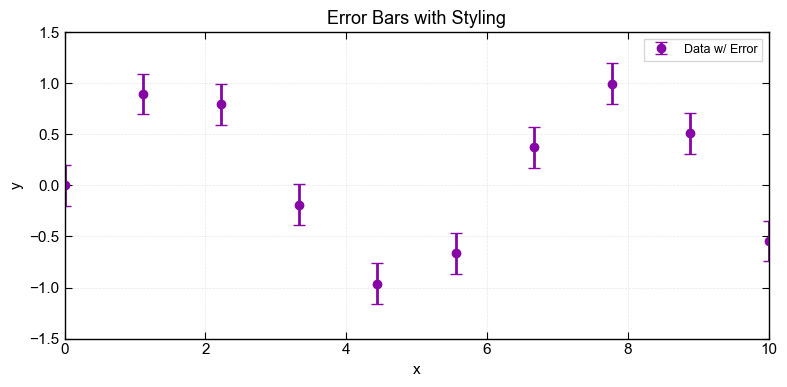

In [11]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

x_err = np.linspace(0, 10, 10)
y_err = np.sin(x_err)
err   = 0.2 * np.ones_like(x_err)

plt.errorbar_styled(x_err, y_err, yerr=err, color_idx=7,
                    linewidth=2, capsize=4, label='Data w/ Error', ax=ax)
plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Error Bars with Styling',
               grid=True, xlim=(0, 10), ylim=(-1.5, 1.5))
ax.legend(loc='upper right', fontsize=9)
mpl_plt.tight_layout()
mpl_plt.show()

## 11 · Markers with Outlines

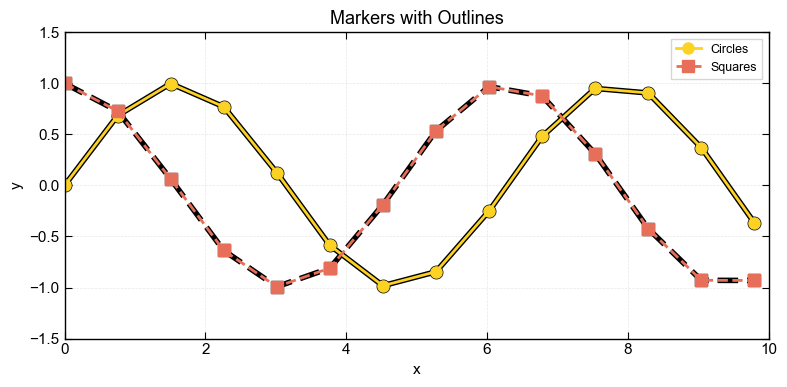

In [12]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

x_sparse = x[::15]
plt.plot_styled(x_sparse, np.sin(x_sparse), color_idx=0,
               marker='o', markersize=8, linestyle='-', linewidth=2,
               label='Circles', outline=True, ax=ax)
plt.plot_styled(x_sparse, np.cos(x_sparse), color_idx=3,
               marker='s', markersize=8, linestyle='--', linewidth=2,
               label='Squares', outline=True, ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Markers with Outlines',
               grid=True, xlim=(0, 10), ylim=(-1.5, 1.5))
ax.legend(loc='upper right', fontsize=9)
mpl_plt.tight_layout()
mpl_plt.show()